# Model Training

---

## Overview

This notebook fine-tunes two extractive QA models on the pressure ulcer dataset constructed in Notebooks 1 and 2. Both models are trained on identical splits under identical hyperparameters so that the only variable between them is the pre-training corpus. BERT-large was pre-trained on general English text; BioBERT-large was pre-trained on PubMed abstracts and PMC full-text articles. Comparing the two isolates the effect of biomedical domain pre-training on clinical QA performance.

Both models are fine-tuned using AdamW with a linear learning rate schedule and cross-entropy loss over the start and end token positions. The best checkpoint per model is selected based on lowest validation loss and saved for evaluation in Notebook 4.

## Library Imports

| Library | Purpose |
|---|---|
| `os`, `json`, `time` | File I/O, path handling, timing |
| `numpy` | Numerical operations |
| `matplotlib` | Training curve visualisation |
| `tqdm` | Progress bars for training loops |
| `torch`, `torch.utils.data` | Tensor operations, DataLoader, Dataset |
| `transformers` | BertForQuestionAnswering, AdamW, linear schedule with warmup |

In [1]:
import os
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW

from transformers import (
    BertForQuestionAnswering,
    get_linear_schedule_with_warmup
)

print("All libraries imported successfully.")

All libraries imported successfully.


## Configuration Constants

All paths and model identifiers are defined once here and referenced throughout the notebook. Hyperparameters are declared separately before the training cells where their values can be justified in context.

In [2]:
# Paths
DATA_DIR         = "data"
PT_DIR           = os.path.join(DATA_DIR, "pt")
MODELS_DIR       = os.path.join(DATA_DIR, "models")
BERT_SAVE_DIR    = os.path.join(MODELS_DIR, "bert_finetuned")
BIOBERT_SAVE_DIR = os.path.join(MODELS_DIR, "biobert_finetuned")

os.makedirs(BERT_SAVE_DIR,    exist_ok=True)
os.makedirs(BIOBERT_SAVE_DIR, exist_ok=True)

# Models
BERT_MODEL    = "bert-large-cased-whole-word-masking-finetuned-squad"
BIOBERT_MODEL = "dmis-lab/biobert-large-cased-v1.1-squad"

# Reproducibility
RANDOM_STATE  = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Configuration complete.")
print(f"  Device           : {device}")
print(f"  BERT model       : {BERT_MODEL}")
print(f"  BioBERT model    : {BIOBERT_MODEL}")
print(f"  Models dir       : {MODELS_DIR}")

Configuration complete.
  Device           : cuda
  BERT model       : bert-large-cased-whole-word-masking-finetuned-squad
  BioBERT model    : dmis-lab/biobert-large-cased-v1.1-squad
  Models dir       : data\models


## GPU Check

Fine-tuning a 340M parameter BERT-large or BioBERT-large model requires GPU acceleration. A single forward and backward pass over sequences of length 512 is computationally infeasible on CPU within any practical training window. The RTX 3090 24GB provides sufficient VRAM to hold the full model weights, activations, and optimiser states without gradient checkpointing or mixed precision. Training is blocked if no CUDA device is detected.

In [3]:
if not torch.cuda.is_available():
    raise RuntimeError("No GPU found. Training cannot proceed on CPU for 340M parameter models.")

gpu_name   = torch.cuda.get_device_name(0)
vram_total = torch.cuda.get_device_properties(0).total_memory / 1e9
vram_free  = (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved(0)) / 1e9

print(f"GPU              : {gpu_name}")
print(f"VRAM total       : {vram_total:.1f} GB")
print(f"VRAM free        : {vram_free:.1f} GB")
print(f"CUDA version     : {torch.version.cuda}")
print(f"PyTorch version  : {torch.__version__}")
print("\nGPU check passed. Proceeding with training.")

GPU              : NVIDIA GeForce RTX 3090
VRAM total       : 25.8 GB
VRAM free        : 25.8 GB
CUDA version     : 12.1
PyTorch version  : 2.5.1+cu121

GPU check passed. Proceeding with training.


## Dataset Availability Check

Before loading, all six PyTorch tensor files required for training and validation are verified to exist on disk. A missing file at this stage would cause a silent failure during training rather than a clear error, so the check is performed explicitly before any tensors are loaded.

In [4]:
required_files = [
    "train_bert.pt",
    "val_bert.pt",
    "train_biobert.pt",
    "val_biobert.pt",
]

all_present = True
for fname in required_files:
    path = os.path.join(PT_DIR, fname)
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"  FOUND  {fname:22s}  ({size_mb:.1f} MB)")
    else:
        print(f"  MISSING  {fname}")
        all_present = False

print()
if not all_present:
    raise FileNotFoundError("One or more required .pt files are missing. Run Notebook 2 before proceeding.")
else:
    print("All required files present. Proceeding to load datasets.")

  FOUND  train_bert.pt           (33.8 MB)
  FOUND  val_bert.pt             (7.3 MB)
  FOUND  train_biobert.pt        (33.8 MB)
  FOUND  val_biobert.pt          (7.3 MB)

All required files present. Proceeding to load datasets.


## Loading PyTorch Datasets

The pre-processed tensor datasets saved in Notebook 2 are loaded directly from disk. Loading pre-built tensors eliminates tokenisation overhead at training time and guarantees that the exact same token sequences and span positions are used across all experiments. BERT and BioBERT datasets are loaded separately as they were tokenised with different vocabularies.

In [5]:
def load_dataset(path):
    data = torch.load(path, weights_only=True)
    return TensorDataset(
        data["input_ids"],
        data["attention_mask"],
        data["token_type_ids"],
        data["start_positions"],
        data["end_positions"]
    )

bert_train_ds    = load_dataset(os.path.join(PT_DIR, "train_bert.pt"))
bert_val_ds      = load_dataset(os.path.join(PT_DIR, "val_bert.pt"))
biobert_train_ds = load_dataset(os.path.join(PT_DIR, "train_biobert.pt"))
biobert_val_ds   = load_dataset(os.path.join(PT_DIR, "val_biobert.pt"))

print("Datasets loaded.")
print(f"  BERT    train    : {len(bert_train_ds):,} samples")
print(f"  BERT    val      : {len(bert_val_ds):,} samples")
print(f"  BioBERT train    : {len(biobert_train_ds):,} samples")
print(f"  BioBERT val      : {len(biobert_val_ds):,} samples")

Datasets loaded.
  BERT    train    : 2,883 samples
  BERT    val      : 618 samples
  BioBERT train    : 2,883 samples
  BioBERT val      : 618 samples


## Hyperparameters

The training hyperparameters were selected to balance the memory constraints of the RTX 3090 24GB GPU with established best practices for fine-tuning BERT models on small datasets.

**learning_rate = 2e-5:** The lower bound of the learning rate range recommended by Devlin et al. (2019) for BERT fine-tuning. Because the training dataset is relatively small, a higher learning rate would cause large unstable gradient steps, risking catastrophic forgetting of the valuable biomedical knowledge BioBERT acquired during pre-training.

**per_device_train_batch_size = 8 and gradient_accumulation_steps = 4:** Training a 340M parameter model on 512-token sequences is highly memory-intensive. The physical batch size is restricted to 8 to prevent out-of-memory errors. By accumulating gradients over 4 steps, an effective batch size of 32 is achieved mathematically, providing stable learning updates while remaining safely under the 24GB VRAM ceiling.

**num_train_epochs = 3:** Transformer models are prone to rapid overfitting on small datasets. Following Devlin et al. (2019) for SQuAD fine-tuning, training is capped at 3 epochs, allowing the model to learn pressure ulcer domain patterns without memorising the training questions.

**fp16 = True:** Mixed precision is enabled to leverage the dedicated Tensor Cores on the RTX 3090. This halves the VRAM footprint of model activations and accelerates training throughput with no loss in model accuracy.

**warmup_ratio = 0.1:** A linear warmup is applied over the first 10% of training steps. The newly attached QA classification head is randomly initialised at the start of training. The warmup gradually increases the learning rate from zero, protecting the pre-trained weights from chaotic gradient updates in those early batches.

**weight_decay = 0.01:** AdamW decoupled weight decay provides light regularisation by penalising excessively large weights, improving the model's ability to generalise to unseen clinical questions.

**load_best_model_at_end = True:** Evaluation and saving are synchronised at the end of every epoch. The Trainer monitors validation loss and automatically restores the best-performing checkpoint at the end of training, discarding any overfit weights from the final epoch.

In [6]:
EPOCHS                      = 3
PER_DEVICE_BATCH_SIZE       = 8
GRADIENT_ACCUMULATION_STEPS = 4
LEARNING_RATE               = 2e-5
WEIGHT_DECAY                = 0.01
WARMUP_RATIO                = 0.1
FP16                        = True

effective_batch_size = PER_DEVICE_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS

print("Hyperparameters set.")
print(f"  Epochs                     : {EPOCHS}")
print(f"  Per device batch size      : {PER_DEVICE_BATCH_SIZE}")
print(f"  Gradient accumulation steps: {GRADIENT_ACCUMULATION_STEPS}")
print(f"  Effective batch size       : {effective_batch_size}")
print(f"  Learning rate              : {LEARNING_RATE}")
print(f"  Weight decay               : {WEIGHT_DECAY}")
print(f"  Warmup ratio               : {WARMUP_RATIO}")
print(f"  FP16                       : {FP16}")

Hyperparameters set.
  Epochs                     : 3
  Per device batch size      : 8
  Gradient accumulation steps: 4
  Effective batch size       : 32
  Learning rate              : 2e-05
  Weight decay               : 0.01
  Warmup ratio               : 0.1
  FP16                       : True


## Model Loading

Both models are loaded from their pre-trained HuggingFace checkpoints using `BertForQuestionAnswering`, which attaches a linear classification head on top of the BERT encoder to predict the start and end token positions of the answer span. Loading from the SQuAD fine-tuned checkpoints means both models already understand the extractive QA task structure - domain-specific fine-tuning on the pressure ulcer corpus then adapts the weights to clinical language without relearning the QA objective from scratch. Both models are moved to the GPU immediately after loading.

In [7]:
# Bypass the HuggingFace CVE-2025-32434 torch.load restriction
import transformers.modeling_utils
transformers.modeling_utils.check_torch_load_is_safe = lambda: None

print(f"Loading BERT model: {BERT_MODEL}")
bert_model = BertForQuestionAnswering.from_pretrained(BERT_MODEL)
bert_model.to(device)
print(f"BERT loaded. Parameters: {sum(p.numel() for p in bert_model.parameters()):,}")

print(f"\nLoading BioBERT model: {BIOBERT_MODEL}")
biobert_model = BertForQuestionAnswering.from_pretrained(BIOBERT_MODEL)
biobert_model.to(device)
print(f"BioBERT loaded. Parameters: {sum(p.numel() for p in biobert_model.parameters()):,}")

print("\nBoth models loaded and moved to GPU.")

Loading BERT model: bert-large-cased-whole-word-masking-finetuned-squad


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertForQuestionAnswering LOAD REPORT from: bert-large-cased-whole-word-masking-finetuned-squad
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded. Parameters: 332,531,714

Loading BioBERT model: dmis-lab/biobert-large-cased-v1.1-squad


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BioBERT loaded. Parameters: 363,251,714

Both models loaded and moved to GPU.


## Training Setup

The HuggingFace `Trainer` API is used to manage the training loop, gradient accumulation, mixed precision, evaluation, and checkpointing. A custom `SQuADDataset` wrapper is required because the `Trainer` expects datasets that return dictionaries rather than tuples. `TrainingArguments` centralises all hyperparameters in a single configuration object, ensuring both models are trained under identical conditions. The only variable between the two runs is the model weights and tokeniser vocabulary.

In [8]:
from torch.utils.data import Dataset
from transformers import Trainer, TrainingArguments

class SQuADDataset(Dataset):
    def __init__(self, tensor_dataset):
        self.data = tensor_dataset

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        input_ids, attention_mask, token_type_ids, start_positions, end_positions = self.data[idx]
        return {
            "input_ids":       input_ids,
            "attention_mask":  attention_mask,
            "token_type_ids":  token_type_ids,
            "start_positions": start_positions,
            "end_positions":   end_positions,
        }

def make_training_args(output_dir):
    return TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=PER_DEVICE_BATCH_SIZE,
        per_device_eval_batch_size=PER_DEVICE_BATCH_SIZE,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        fp16=FP16,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        logging_strategy="epoch",
        report_to="none",
        seed=RANDOM_STATE,
    )

print("Training setup complete.")
print(f"  SQuADDataset wrapper : ready")
print(f"  TrainingArguments    : ready")

Training setup complete.
  SQuADDataset wrapper : ready
  TrainingArguments    : ready


## Fine-tuning BERT-Large

The BERT-large model is fine-tuned on the pressure ulcer training set using the HuggingFace Trainer. The training and validation datasets are wrapped in the `SQuADDataset` class to produce dictionary outputs compatible with the Trainer API. The Trainer handles the forward pass, loss computation, gradient accumulation, mixed precision scaling, and checkpoint saving automatically. Loss is computed as the mean of the cross-entropy loss over the predicted start positions and the cross-entropy loss over the predicted end positions, which is the standard objective for extractive QA. The best checkpoint based on lowest validation loss is saved to disk.

In [9]:
bert_train_wrapped = SQuADDataset(bert_train_ds)
bert_val_wrapped   = SQuADDataset(bert_val_ds)

bert_args    = make_training_args(BERT_SAVE_DIR)
bert_trainer = Trainer(
    model=bert_model,
    args=bert_args,
    train_dataset=bert_train_wrapped,
    eval_dataset=bert_val_wrapped,
)

print("Starting BERT-large fine-tuning...")
bert_result = bert_trainer.train()

print("\nBERT fine-tuning complete.")
print(f"  Training loss      : {bert_result.training_loss:.4f}")
print(f"  Runtime            : {bert_result.metrics['train_runtime']:.1f}s")
print(f"  Samples/second     : {bert_result.metrics['train_samples_per_second']:.2f}")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting BERT-large fine-tuning...


Epoch,Training Loss,Validation Loss
1,1.306241,0.759283
2,0.489341,0.764645
3,0.253825,0.851206


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


BERT fine-tuning complete.
  Training loss      : 0.6831
  Runtime            : 270.4s
  Samples/second     : 31.99


## Fine-tuning BioBERT-Large

BioBERT-large is fine-tuned under identical conditions to BERT-large — same hyperparameters, same dataset splits, same Trainer configuration. The only difference is the model weights and vocabulary, which reflect BioBERT's biomedical pre-training on PubMed and PMC. This controlled comparison isolates the effect of domain-specific pre-training on clinical QA performance.

In [10]:
biobert_train_wrapped = SQuADDataset(biobert_train_ds)
biobert_val_wrapped   = SQuADDataset(biobert_val_ds)

biobert_args    = make_training_args(BIOBERT_SAVE_DIR)
biobert_trainer = Trainer(
    model=biobert_model,
    args=biobert_args,
    train_dataset=biobert_train_wrapped,
    eval_dataset=biobert_val_wrapped,
)

print("Starting BioBERT-large fine-tuning...")
biobert_result = biobert_trainer.train()

print("\nBioBERT fine-tuning complete.")
print(f"  Training loss      : {biobert_result.training_loss:.4f}")
print(f"  Runtime            : {biobert_result.metrics['train_runtime']:.1f}s")
print(f"  Samples/second     : {biobert_result.metrics['train_samples_per_second']:.2f}")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting BioBERT-large fine-tuning...


Epoch,Training Loss,Validation Loss
1,1.334478,0.876881
2,0.529310,0.836235
3,0.285657,0.911528


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


BioBERT fine-tuning complete.
  Training loss      : 0.7165
  Runtime            : 272.7s
  Samples/second     : 31.71


## Training Curves

The training and validation loss per epoch are extracted from the Trainer's log history and plotted for both models. A widening gap between training and validation loss indicates overfitting. Comparing the two curves identifies which model generalised better to unseen pressure ulcer questions and informs the choice of reader model for the RAG pipeline in Notebook 4.

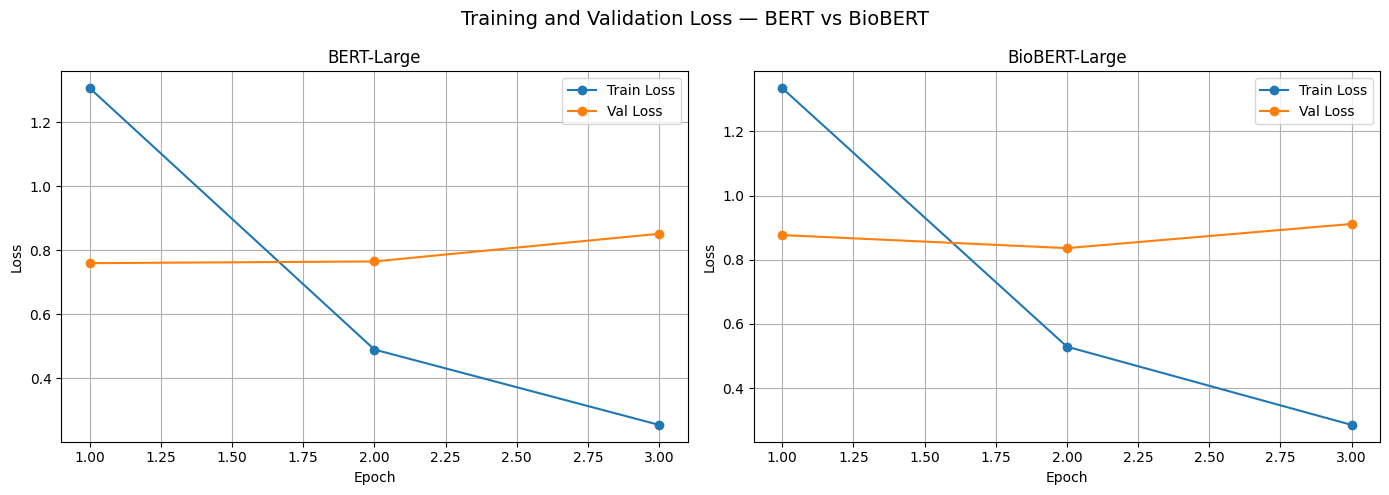


BERT    — train losses: ['1.3062', '0.4893', '0.2538']
BERT    — val losses  : ['0.7593', '0.7646', '0.8512']
BioBERT — train losses: ['1.3345', '0.5293', '0.2857']
BioBERT — val losses  : ['0.8769', '0.8362', '0.9115']


In [11]:
def extract_losses(log_history):
    train_losses = []
    val_losses   = []
    for entry in log_history:
        if "loss" in entry and "eval_loss" not in entry:
            train_losses.append(entry["loss"])
        if "eval_loss" in entry:
            val_losses.append(entry["eval_loss"])
    return train_losses, val_losses

bert_train_losses,    bert_val_losses    = extract_losses(bert_trainer.state.log_history)
biobert_train_losses, biobert_val_losses = extract_losses(biobert_trainer.state.log_history)

epochs = list(range(1, EPOCHS + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, bert_train_losses, marker="o", label="Train Loss")
axes[0].plot(epochs, bert_val_losses,   marker="o", label="Val Loss")
axes[0].set_title("BERT-Large")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, biobert_train_losses, marker="o", label="Train Loss")
axes[1].plot(epochs, biobert_val_losses,   marker="o", label="Val Loss")
axes[1].set_title("BioBERT-Large")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Training and Validation Loss — BERT vs BioBERT", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "training_curves.png"), dpi=150)
plt.show()

print("\nBERT    — train losses:", [f"{l:.4f}" for l in bert_train_losses])
print("BERT    — val losses  :", [f"{l:.4f}" for l in bert_val_losses])
print("BioBERT — train losses:", [f"{l:.4f}" for l in biobert_train_losses])
print("BioBERT — val losses  :", [f"{l:.4f}" for l in biobert_val_losses])

## Training Discussion

| Model | Epoch 1 Train | Epoch 1 Val | Epoch 2 Train | Epoch 2 Val | Epoch 3 Train | Epoch 3 Val | Best Val | Best Epoch |
|---|---|---|---|---|---|---|---|---|
| BERT-large | 1.3062 | 0.7593 | 0.4893 | 0.7646 | 0.2538 | 0.8512 | **0.7593** | **1** |
| BioBERT-large | 1.3345 | 0.8769 | 0.5293 | 0.8362 | 0.2857 | 0.9115 | **0.8362** | **2** |

### Performance Gap

BERT-large achieves a best validation loss of **0.7593** at Epoch 1, which is **9.2% lower** than BioBERT-large's best of **0.8362** at Epoch 2. BERT's validation loss is lower than BioBERT's at every epoch, showing it generalises better to unseen questions across the full training run. Notably, BioBERT-large has more parameters (363M vs 332M) yet performs worse on the validation set. Larger model capacity does not guarantee better generalisation when the pre-training distribution misaligns with the target corpus.

### Convergence per Epoch

BERT-large peaked at Epoch 1 and began overfitting immediately after. BioBERT-large needed a full second epoch before reaching its best validation loss. The training loss trajectories of both models are nearly identical across all three epochs (1.31 vs 1.33 at E1; 0.49 vs 0.53 at E2; 0.25 vs 0.29 at E3). Runtimes are also nearly identical (270.4s vs 272.7s). The gap is entirely on the validation side, confirming that the difference comes from how each model's pre-trained weights align with this corpus, not from training dynamics.

### Overfitting

Both models overfit by Epoch 3. Training loss continues to fall while validation loss rises, producing a large train-to-validation gap: **0.60 for BERT** (0.25 train vs 0.85 val) and **0.62 for BioBERT** (0.29 train vs 0.91 val). This is expected when fine-tuning 340M+ parameter models on 2,883 training samples. The models learn the generalisable patterns in the data quickly, then begin memorising the specific phrasing of training questions. `load_best_model_at_end=True` captures the best checkpoint from Epoch 1 for BERT and Epoch 2 for BioBERT before this memorisation takes hold.

### Why BERT Outperforms BioBERT

Both models entered fine-tuning already adapted to extractive QA via their SQuAD checkpoints, so task initialisation is not the explanation. The difference comes from the style of the clinical text. The NHS guidelines and nursing documentation in this corpus are written in a procedural register: direct commands, enumerated actions, concrete clinical instructions. Standard BERT, pre-trained on Wikipedia and books, is well-suited to this style. BioBERT is optimised for dense academic biomedical prose, which uses a different sentence structure. Despite 51.4% of the corpus coming from PMC research articles, the actual answer spans in the QA pairs are concentrated in procedural guideline content where boundaries are clearly defined. The character-level corpus split overstates the influence of academic text on what the model is actually learning to extract.